# IN4640 Machine Vision
## Assignment 2 on Fitting and Alignment
### 215546F Premarathna TUMN
---

## Question 01

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
D = np.genfromtxt("assets/lines.csv", delimiter=",", skip_header=1)

X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

print("Data shape:", D.shape)
print("First 5 rows:")
print(D[:5])

Data shape: (100, 6)
First 5 rows:
[[ -5.30547099  -4.06009155  -5.26129006 -12.66633342  -3.79615021
    3.69171161]
 [ -5.5403588   -5.0031803   -3.99259187 -11.00772693  -3.98562503
    4.90000402]
 [ -4.98212753  -4.58449362  -4.33122591 -11.69731474  -3.58927699
    5.04686274]
 [ -4.49570614  -5.06413838  -4.78201809 -11.97801037  -3.59707103
    4.63593624]
 [ -4.44215386  -4.41137023  -4.5675092  -12.41495176  -2.79950409
    4.73969871]]


In [3]:
def total_least_squares(x, y):
    """Fit a line y = m*x + b using Total Least Squares (SVD/PCA).

    Returns
    -------
    m : float  slope
    b : float  intercept
    normal : ndarray  unit normal vector [n_x, n_y]
    """
    x_mean, y_mean = x.mean(), y.mean()
    A = np.column_stack([x - x_mean, y - y_mean])
    _, _, Vt = np.linalg.svd(A, full_matrices=False)
    # normal is the last row of Vt (smallest singular value)
    normal = Vt[-1]          # [n_x, n_y]
    n_x, n_y = normal
    m = -n_x / n_y
    b = y_mean - m * x_mean
    return m, b, normal


# First line uses columns x1, y1
x1 = D[:, 0]
y1 = D[:, 3]

m_tls, b_tls, normal_tls = total_least_squares(x1, y1)

print("=== Total Least Squares — Line 1 ===")
print(f"  Slope  m = {m_tls:.6f}")
print(f"  Intercept b = {b_tls:.6f}")
print(f"  Line equation: y = {m_tls:.4f}·x + ({b_tls:.4f})")
print(f"  Normal vector: {normal_tls}")

=== Total Least Squares — Line 1 ===
  Slope  m = 1.220666
  Intercept b = -5.987165
  Line equation: y = 1.2207·x + (-5.9872)
  Normal vector: [ 0.77356165 -0.63372105]


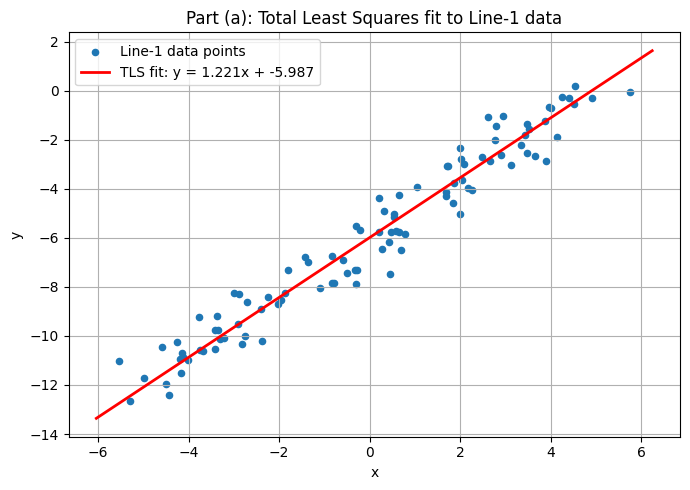

In [4]:
x_plot = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 200)
y_plot = m_tls * x_plot + b_tls

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x1, y1, s=20, label="Line-1 data points")
ax.plot(x_plot, y_plot, "r-", linewidth=2,
        label=f"TLS fit: y = {m_tls:.3f}x + {b_tls:.3f}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Part (a): Total Least Squares fit to Line-1 data")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [5]:
def ransac_line(x, y, n_iter=1000, threshold=0.5, min_inliers=10, rng=None):
    """RANSAC line fitting using Total Least Squares on the consensus set.

    Parameters
    ----------
    x, y        : 1-D arrays of point coordinates
    n_iter      : number of RANSAC iterations
    threshold   : perpendicular distance threshold for inlier classification
    min_inliers : minimum number of inliers to accept a model
    rng         : numpy Generator for reproducibility

    Returns
    -------
    best_m, best_b : slope and intercept of the best line
    inlier_mask    : boolean mask of inlier points
    """
    if rng is None:
        rng = np.random.default_rng(42)

    n = len(x)
    best_inliers = np.zeros(n, dtype=bool)
    best_count = 0

    for _ in range(n_iter):
        # Minimal sample: 2 points
        idx = rng.choice(n, size=2, replace=False)
        xs, ys = x[idx], y[idx]

        # Line through 2 points: direction vector
        d = np.array([xs[1] - xs[0], ys[1] - ys[0]], dtype=float)
        norm_d = np.linalg.norm(d)
        if norm_d < 1e-10:
            continue
        d /= norm_d
        # Normal to the line
        n_vec = np.array([-d[1], d[0]])

        # Perpendicular distance of all points to this line
        dist = np.abs((x - xs[0]) * n_vec[0] + (y - ys[0]) * n_vec[1])
        inliers = dist < threshold
        count = inliers.sum()

        if count > best_count and count >= min_inliers:
            best_count = count
            best_inliers = inliers

    # Refit using TLS on the full consensus set
    if best_count >= 2:
        best_m, best_b, _ = total_least_squares(x[best_inliers], y[best_inliers])
    else:
        best_m, best_b = np.nan, np.nan

    return best_m, best_b, best_inliers

In [6]:
rng = np.random.default_rng(0)

lines = []
remaining = np.ones(len(X_all), dtype=bool)  # all points active

for i in range(3):
    x_rem = X_all[remaining]
    y_rem = Y_all[remaining]

    m_r, b_r, inlier_local = ransac_line(
        x_rem, y_rem,
        n_iter=2000,
        threshold=0.4,
        min_inliers=15,
        rng=rng
    )

    # Map local inlier mask back to the global index space
    global_indices = np.where(remaining)[0]
    inlier_global = np.zeros(len(X_all), dtype=bool)
    inlier_global[global_indices[inlier_local]] = True

    lines.append((m_r, b_r, inlier_global))

    # Mask the consensus set before next iteration
    remaining[inlier_global] = False

    print(f"Line {i+1}: y = {m_r:.4f}·x + ({b_r:.4f})  "
          f"| inliers = {inlier_global.sum()}  "
          f"| remaining = {remaining.sum()}")

Line 1: y = -0.5043·x + (2.0751)  | inliers = 74  | remaining = 226
Line 2: y = 1.1123·x + (1.1215)  | inliers = 59  | remaining = 167
Line 3: y = 1.2616·x + (-5.8306)  | inliers = 56  | remaining = 111


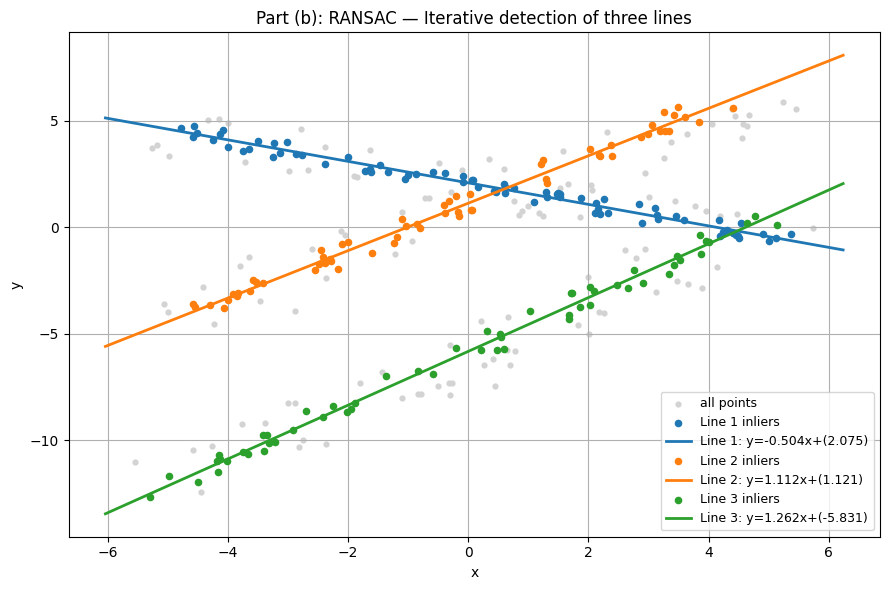

In [7]:
colors = ["tab:blue", "tab:orange", "tab:green"]
x_range = np.linspace(X_all.min() - 0.5, X_all.max() + 0.5, 300)

fig, ax = plt.subplots(figsize=(9, 6))

# Plot all points in grey first, then colour inliers
ax.scatter(X_all, Y_all, s=12, color="lightgrey", zorder=1, label="all points")

for i, (m_r, b_r, mask) in enumerate(lines):
    ax.scatter(X_all[mask], Y_all[mask], s=20, color=colors[i],
               zorder=2, label=f"Line {i+1} inliers")
    y_line = m_r * x_range + b_r
    ax.plot(x_range, y_line, color=colors[i], linewidth=2,
            label=f"Line {i+1}: y={m_r:.3f}x+({b_r:.3f})")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Part (b): RANSAC — Iterative detection of three lines")
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

---
## Question 02 — Physical Size of Earrings from Camera Parameters

**Given:**
- Focal length: $f = 8\,\text{mm}$
- Pixel size: $p = 2.2\,\mu\text{m} = 0.0022\,\text{mm}$
- Distance from lens to the flat earring plane: $Z = 720\,\text{mm}$

**Thin-lens equation** gives the image distance $d_i$:

$$\frac{1}{f} = \frac{1}{Z} + \frac{1}{d_i} \implies d_i = \frac{fZ}{Z - f}$$

**Magnification** $M = d_i / Z$

**Physical scale** (real-world mm per pixel):

$$\text{scale} = \frac{p}{M} = \frac{p \cdot Z}{d_i}$$

Any object of $n$ pixels corresponds to a real size of $n \times \text{scale}$ mm.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

# ── Camera parameters ──────────────────────────────────────────────────────
f          = 8.0          # focal length  [mm]
pixel_size = 2.2e-3       # pixel pitch   [mm]  (2.2 µm)
Z          = 720.0        # object distance (lens → earring plane)  [mm]

# Thin-lens: image distance
d_i = (f * Z) / (Z - f)

# Lateral magnification
M = d_i / Z

# Real-world scale: mm of real object per pixel in the image
scale_mm_per_px = pixel_size / M          # = pixel_size * Z / d_i
scale_um_per_px = scale_mm_per_px * 1000  # in µm for readability

print("=== Camera Geometry ===")
print(f"  Focal length        f  = {f} mm")
print(f"  Object distance     Z  = {Z} mm")
print(f"  Image distance      d_i = {d_i:.4f} mm")
print(f"  Magnification       M  = {M:.6f}")
print(f"  Scale               = {scale_mm_per_px:.6f} mm/pixel")
print(f"                      = {scale_um_per_px:.4f} µm/pixel")

=== Camera Geometry ===
  Focal length        f  = 8.0 mm
  Object distance     Z  = 720.0 mm
  Image distance      d_i = 8.0899 mm
  Magnification       M  = 0.011236
  Scale               = 0.195800 mm/pixel
                      = 195.8000 µm/pixel


### Image Processing — Measure the Earrings

Steps:
1. Load `earrings.jpg` and convert to grayscale.
2. Apply Gaussian blur then Otsu thresholding to separate earrings from background.
3. Find external contours and filter out noise (small blobs).
4. For each earring contour measure its bounding-box width and height in pixels.
5. Multiply by `scale_mm_per_px` to get real dimensions.

In [9]:
img_path = "assets/earrings.jpg"
img_bgr  = cv2.imread(img_path)

if img_bgr is None:
    raise FileNotFoundError(f"Could not load '{img_path}'. "
                            "Place earrings.jpg in the assets/ folder.")

img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"Image shape : {img_rgb.shape}  (H × W × C)")
print(f"Image size  : {img_rgb.shape[1]} × {img_rgb.shape[0]} pixels")

# ── Pre-processing ──────────────────────────────────────────────────────────
blurred = cv2.GaussianBlur(img_gray, (7, 7), 0)

# Otsu threshold — works well when background is clearly lighter/darker
_, thresh = cv2.threshold(blurred, 0, 255,
                          cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Morphological closing to fill small holes inside earrings
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

# ── Contour detection ───────────────────────────────────────────────────────
contours, _ = cv2.findContours(thresh_clean,
                               cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

# Keep only contours large enough to be an earring
img_area   = img_rgb.shape[0] * img_rgb.shape[1]
min_area   = img_area * 0.005   # at least 0.5 % of image area
earring_contours = [c for c in contours if cv2.contourArea(c) > min_area]
earring_contours = sorted(earring_contours,
                          key=lambda c: cv2.boundingRect(c)[0])  # left → right

print(f"\nFound {len(earring_contours)} earring region(s).")

Image shape : (1024, 1024, 3)  (H × W × C)
Image size  : 1024 × 1024 pixels

Found 2 earring region(s).


Earring 1:
  Bounding box : 375 × 394  px
  Physical size: 73.43 × 77.15  mm
  Contour area : 4337.35  mm²

Earring 2:
  Bounding box : 375 × 394  px
  Physical size: 73.43 × 77.15  mm
  Contour area : 4335.89  mm²



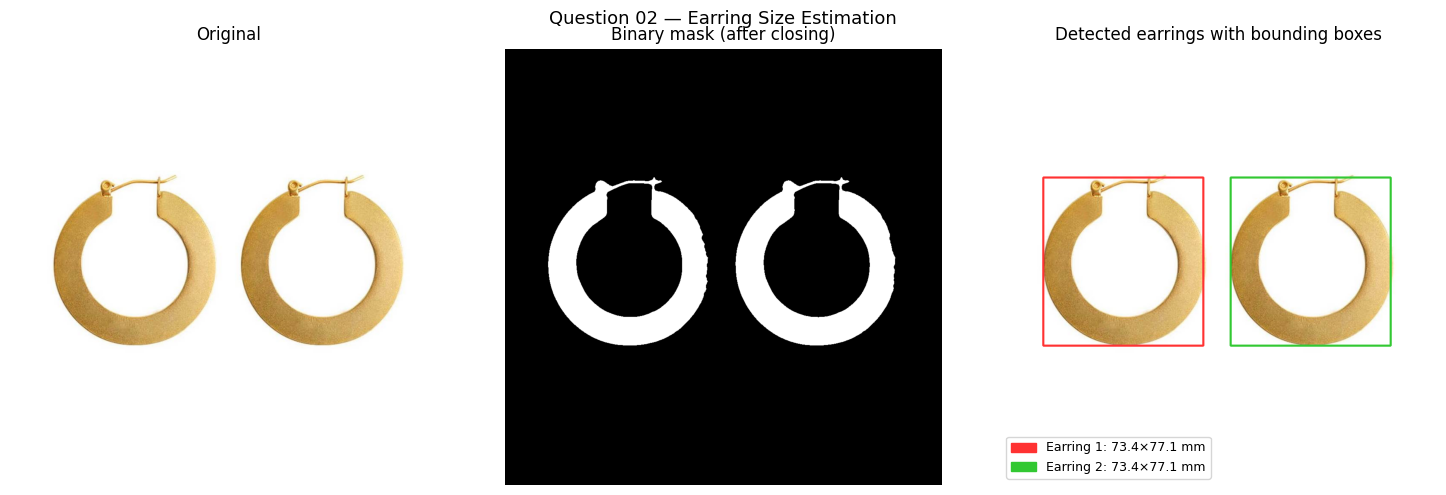

In [10]:
# ── Measure each earring ────────────────────────────────────────────────────
results = []
for idx, cnt in enumerate(earring_contours, start=1):
    x, y, w, h = cv2.boundingRect(cnt)
    w_mm = w * scale_mm_per_px
    h_mm = h * scale_mm_per_px
    area_px2 = cv2.contourArea(cnt)
    area_mm2 = area_px2 * (scale_mm_per_px ** 2)
    results.append(dict(idx=idx, x=x, y=y, w_px=w, h_px=h,
                        w_mm=w_mm, h_mm=h_mm, area_mm2=area_mm2))
    print(f"Earring {idx}:")
    print(f"  Bounding box : {w} × {h}  px")
    print(f"  Physical size: {w_mm:.2f} × {h_mm:.2f}  mm")
    print(f"  Contour area : {area_mm2:.2f}  mm²")
    print()

# ── Visualisation ───────────────────────────────────────────────────────────
colors_vis = [(255, 50, 50), (50, 200, 50), (50, 100, 255),
              (255, 200, 0), (200, 50, 255)]

overlay = img_rgb.copy()
for r in results:
    col = colors_vis[(r['idx'] - 1) % len(colors_vis)]
    cv2.rectangle(overlay,
                  (r['x'], r['y']),
                  (r['x'] + r['w_px'], r['y'] + r['h_px']),
                  col, 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(thresh_clean, cmap="gray")
axes[1].set_title("Binary mask (after closing)")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Detected earrings with bounding boxes")
axes[2].axis("off")

# Legend patches
patches = [mpatches.Patch(
               color=[c/255 for c in colors_vis[(r['idx']-1) % len(colors_vis)]],
               label=f"Earring {r['idx']}: "
                     f"{r['w_mm']:.1f}×{r['h_mm']:.1f} mm")
           for r in results]
axes[2].legend(handles=patches, loc="lower left", fontsize=9)

plt.suptitle("Question 02 — Earring Size Estimation", fontsize=13)
plt.tight_layout()
plt.show()

---
## Question 03 — Superimpose a Country Flag on the Cricket Turf

**Approach:**
1. Load the turf image and the Sri Lanka flag.
2. **Interactively** click 4 corners of the playing surface (TL → TR → BR → BL).  
   A fallback set of default corners is used when clicking is skipped.
3. Compute a **perspective homography** that maps the flag's four corners to the selected quadrangle on the turf.
4. Warp the flag with `cv2.warpPerspective` and **alpha-blend** it onto the turf.

The same `cv2` mouse-callback logic from Listing 1 is reproduced inside the notebook using `matplotlib`'s `ginput`, which works natively in Jupyter.

Turf image : 1400 × 933 pixels
Flag image : 1280 × 640 pixels, 4 channels


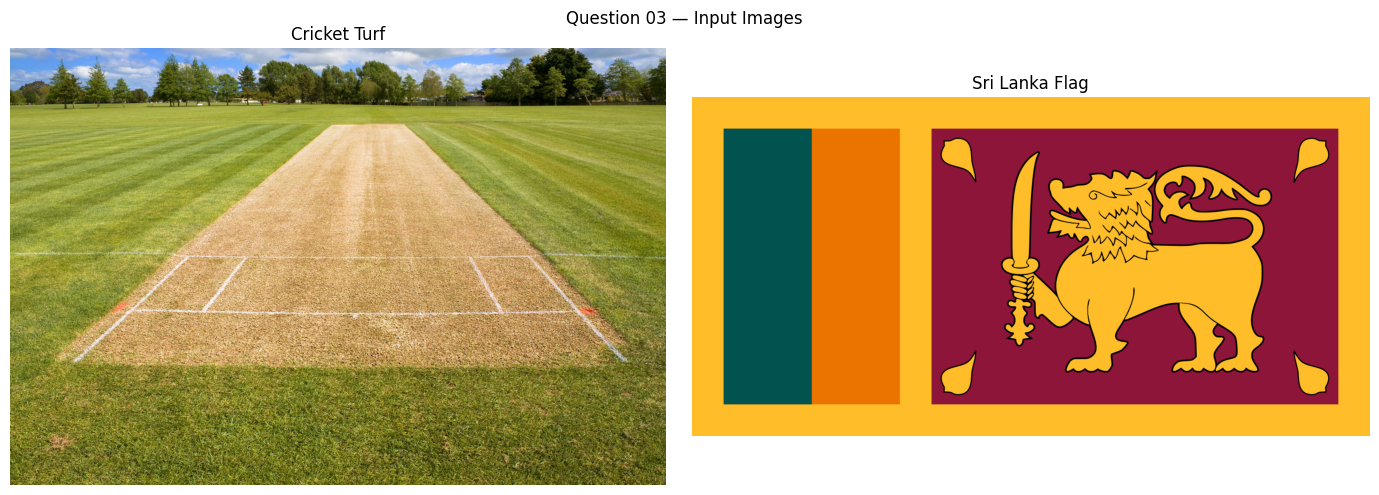

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Load images ──────────────────────────────────────────────────────────────
turf_bgr = cv2.imread("assets/turf.jpg")
if turf_bgr is None:
    raise FileNotFoundError("assets/turf.jpg not found.")
turf_rgb = cv2.cvtColor(turf_bgr, cv2.COLOR_BGR2RGB)
H_t, W_t = turf_rgb.shape[:2]

# Load flag — keep alpha channel if present
flag_bgr = cv2.imread("assets/Flag_of_Sri_Lanka.png", cv2.IMREAD_UNCHANGED)
if flag_bgr is None:
    raise FileNotFoundError("assets/Flag_of_Sri_Lanka.png not found.")

if flag_bgr.ndim == 3 and flag_bgr.shape[2] == 4:
    flag_rgba = cv2.cvtColor(flag_bgr, cv2.COLOR_BGRA2RGBA)
else:
    flag_rgb_only = cv2.cvtColor(flag_bgr, cv2.COLOR_BGR2RGB)
    alpha_full = np.full(flag_rgb_only.shape[:2], 255, dtype=np.uint8)
    flag_rgba = np.dstack([flag_rgb_only, alpha_full])

H_f, W_f = flag_rgba.shape[:2]
print(f"Turf image : {W_t} × {H_t} pixels")
print(f"Flag image : {W_f} × {H_f} pixels, {flag_rgba.shape[2]} channels")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(turf_rgb)
axes[0].set_title("Cricket Turf")
axes[0].axis("off")
axes[1].imshow(flag_rgba)
axes[1].set_title("Sri Lanka Flag")
axes[1].axis("off")
plt.suptitle("Question 03 — Input Images", fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
# ── Interactive corner selection using OpenCV (from Listing 1) ──────────
#
# Click 4 corners on the turf where the flag should be placed.
# Press any key after selecting 4 points to continue.
# If fewer than 4 points are clicked, default corners are used.

points = []

def mouse_callback(event, x, y, flags, param):
    global points, img_display
    if event == cv2.EVENT_LBUTTONDOWN:
        if len(points) < 4:
            points.append((x, y))
            print(f"Point {len(points)}: ({x}, {y})")
            cv2.circle(img_display, (x, y), 5, (0, 0, 255), -1)
            cv2.imshow("Image", img_display)
            if len(points) == 4:
                print("\nFour points selected:")
                for i, p in enumerate(points):
                    print(f"P{i+1}: {p}")
                print("Press any key to exit.")

img = cv2.imread("assets/turf.jpg")
if img is None:
    raise FileNotFoundError("Image not found.")

img_display = img.copy()
cv2.namedWindow("Image")
cv2.setMouseCallback("Image", mouse_callback)
cv2.imshow("Image", img_display)
cv2.waitKey(0)
cv2.destroyAllWindows()

if len(points) == 4:
    pts_dst = np.array(points, dtype=np.float32)
    print("\nFinal array of selected points:")
    print(pts_dst)
else:
    print(f"Only {len(points)} click(s) detected — using default perspective corners.")
    pts_dst = np.array([
        [W_t * 0.06, H_t * 0.30],
        [W_t * 0.28, H_t * 0.27],
        [W_t * 0.36, H_t * 0.76],
        [W_t * 0.04, H_t * 0.80],
    ], dtype=np.float32)
    labels = ["Far-left (TL)", "Far-right (TR)", "Near-right (BR)", "Near-left (BL)"]
    print("Default perspective corners:")
    for i, (p, lbl) in enumerate(zip(pts_dst, labels), 1):
        print(f"  P{i}  {lbl:16s} → ({p[0]:.1f}, {p[1]:.1f})")

Point 1: (846, 165)
Point 2: (1170, 162)
Point 3: (1303, 205)
Point 4: (925, 230)

Four points selected:
P1: (846, 165)
P2: (1170, 162)
P3: (1303, 205)
P4: (925, 230)
Press any key to exit.

Final array of selected points:
[[ 846.  165.]
 [1170.  162.]
 [1303.  205.]
 [ 925.  230.]]


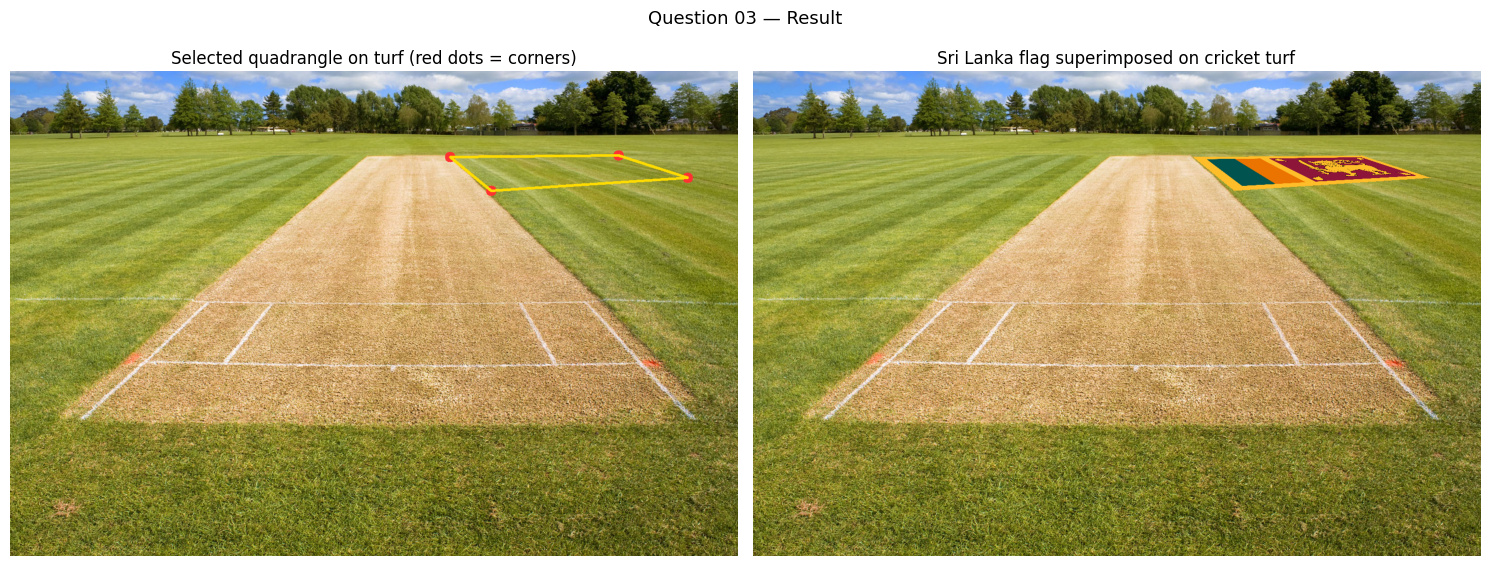

In [29]:
# ── Perspective warp + alpha-blend ────────────────────────────────────────────

# Source corners: the four corners of the flag image itself
pts_src = np.array(
    [[0, 0], [W_f - 1, 0], [W_f - 1, H_f - 1], [0, H_f - 1]],
    dtype=np.float32
)

# 4-point homography: flag image space → turf image space
M = cv2.getPerspectiveTransform(pts_src, pts_dst)

# Warp the full RGBA flag into the turf frame
warped_rgba = cv2.warpPerspective(
    flag_rgba, M, (W_t, H_t),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(0, 0, 0, 0)
)

# Separate RGB and alpha
warped_rgb = warped_rgba[:, :, :3].astype(np.float32)
alpha_w    = warped_rgba[:, :,  3].astype(np.float32) / 255.0  # [0 .. 1]
turf_f     = turf_rgb.astype(np.float32)

# Alpha-composite: result = flag·α + turf·(1−α)
a = alpha_w[..., np.newaxis]
result = (warped_rgb * a + turf_f * (1.0 - a)).clip(0, 255).astype(np.uint8)

# ── Visualisation ─────────────────────────────────────────────────────────────
# Mark the selected quadrangle on the original turf
turf_marked = turf_rgb.copy()
for p in pts_dst:
    cv2.circle(turf_marked, (int(p[0]), int(p[1])), 10, (255, 50, 50), -1)
pts_poly = pts_dst.reshape((-1, 1, 2)).astype(np.int32)
cv2.polylines(turf_marked, [pts_poly], isClosed=True,
              color=(255, 220, 0), thickness=3)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].imshow(turf_marked)
axes[0].set_title("Selected quadrangle on turf (red dots = corners)")
axes[0].axis("off")

axes[1].imshow(result)
axes[1].set_title("Sri Lanka flag superimposed on cricket turf")
axes[1].axis("off")

plt.suptitle("Question 03 — Result", fontsize=13)
plt.tight_layout()
plt.show()